# Tiền xử lý và khám phá dữ liệu
## Phần 1: Tiền xử lý
### Lấy dữ liệu

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Data
DATA_OUT = Path("../data/processed/dim_shop_tiki_theanh.csv")
processed_dir = Path("../data/processed")
data_candidates = [
    processed_dir / "fact_product_enriched.csv",
    processed_dir / "fact_product_merged.csv",
]

data_path = None
for candidate in data_candidates:
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError(
        "Không tìm thấy fact_product_enriched.csv hoac fact_product_merged.csv trong data/processed"
    )

df = pd.read_csv(data_path, encoding="utf-8-sig")
print(f"Data source: {data_path.name} ({len(df)} dòng)")

Data source: fact_product_enriched.csv (9186 dòng)


### Kiểm tra nhất quán và trùng lắp

In [2]:
cols_num = ["price_current", "price_original", "rating", "sold_count"]

for col in cols_num:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


n_dup = df.duplicated(subset=['product_id']).sum()
print("Số product_id trùng:", n_dup)

# Sắp xếp để giữ bản ghi tốt nhất
df = df.sort_values(
    ['product_id', 'sold_count', 'rating'],
    ascending=[True, False, False]
)

# Xóa trùng
before = len(df)
df = df.drop_duplicates(subset=['product_id']).reset_index(drop=True)
after = len(df)

print(f"Đã loại {before - after} dòng trùng → còn {after}")


# Kiểm tra dữ liệu không nhất quán
dup_group = df[df.duplicated('product_id', keep=False)]
if not dup_group.empty:
    inconsistent = dup_group.groupby('product_id').filter(
        lambda x: x.nunique().max() > 1
    )
    print("Product không nhất quán:", inconsistent['product_id'].nunique())


# Sữa lỗi giá
mask = df['price_original'] < df['price_current']
n_price_err = mask.sum()

# xem thử vài dòng lỗi
if n_price_err > 0:
    print("\nVí dụ lỗi giá:")
    print(df[mask][['product_id','price_current','price_original']].head())

# fix
df.loc[mask, 'price_original'] = df.loc[mask, 'price_current']

print(f"Đã sửa {n_price_err} dòng lỗi giá")


# 5. CLEAN 
df = df[df['price_current'].notna()]   # bỏ dòng không có giá
df['sold_count'] = df['sold_count'].fillna(0)
df['rating'] = df['rating'].fillna(0)

Số product_id trùng: 0
Đã loại 0 dòng trùng → còn 9186

Ví dụ lỗi giá:
         product_id  price_current  price_original
20   tiki_101278726       110000.0         97440.0
24   tiki_101279138       155000.0        135000.0
33   tiki_101281211        95000.0         84000.0
133  tiki_106526672       204750.0        199500.0
301  tiki_113144956       124820.0        120000.0
Đã sửa 96 dòng lỗi giá


### Xử lý dữ liệu thiếu

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Số ô thiếu': missing,
    'Tỉ lệ (%)': missing_pct
}).query('`Số ô thiếu` > 0').sort_values('Số ô thiếu', ascending=False)

display(missing_df)



# Giá
df['price_original'] = df[['price_original', 'price_current']].max(axis=1)

# Numeric
df['discount_percent'] = df['discount_percent'].fillna(0.0)
df['sold_count'] = df['sold_count'].fillna(0)
df['review_count'] = df['review_count'].fillna(0)
df['rating'] = df['rating'].fillna(0)

# Count
df['image_count'] = df['image_count'].fillna(1)
df['promotion_label_count'] = df['promotion_label_count'].fillna(0)
df['review_with_image_count'] = df['review_with_image_count'].fillna(0)
df['five_star_with_image_count'] = df['five_star_with_image_count'].fillna(0)

# Boolean
bool_cols = [
    'has_video', 'is_freeship', 'price_ends_with_9',
    'has_freeship_xtra_label', 'has_coinback_label', 'has_voucher_label'
]

for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(bool)

# Text
df['stock'] = df['stock'].fillna('unknown').astype(str)

print("Đã xử lý missing values")

,Số ô thiếu,Tỉ lệ (%)
follower_count,9186,100.00
shop_rating,9186,100.00
estimated_delivery_days,9186,100.00
shipping_fee,9186,100.00
total_products,9186,100.00
response_rate,9186,100.00
location,9154,99.65
stock,6145,66.90
five_star_with_image_count,3855,41.97
review_count,3436,37.40


Đã xử lý missing values


### Chuyển đổi dữ liệu

In [4]:
# ID → string
id_cols = ["product_id", "shop_id", "category_id", "platform_id"]
for col in id_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)


# Numeric (float)
float_cols = [
    "price_current", "price_original",
    "discount_percent", "rating"
]

for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# Numeric (int)
int_cols = [
    "sold_count", "review_count",
    "image_count", "promotion_label_count",
    "review_with_image_count", "five_star_with_image_count"
]

for col in int_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)


# Boolean
bool_cols = [
    "has_video", "is_freeship", "price_ends_with_9",
    "has_freeship_xtra_label", "has_coinback_label", "has_voucher_label"
]

for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(bool)


# Datetime
if "crawled_at" in df.columns:
    df["crawled_at"] = pd.to_datetime(df["crawled_at"], errors="coerce")


print("Đã chuyển đổi kiểu dữ liệu")
df.info()

df.to_csv(DATA_OUT, index=False, encoding='utf-8-sig')

Đã chuyển đổi kiểu dữ liệu
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9186 entries, 0 to 9185
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype                    
---  ------                      --------------  -----                    
 0   product_id                  9186 non-null   object                   
 1   platform_id                 9186 non-null   object                   
 2   category_id                 9186 non-null   object                   
 3   shop_id                     9186 non-null   object                   
 4   platform_name               9186 non-null   object                   
 5   base_url                    9186 non-null   object                   
 6   category_name               9186 non-null   object                   
 7   level                       9186 non-null   int64                    
 8   shop_name                   9186 non-null   object                   
 9   shop_type                   9186 non

## Phần 2: 

In [5]:
df = pd.read_csv(DATA_OUT)

# Kích thước
print("Số dòng, số cột:", df.shape)

# Kiểu dữ liệu
print("\nKiểu dữ liệu:")
print(df.dtypes)

# Thông tin chi tiết
print("\nInfo:")
df.info()


df.describe()


Số dòng, số cột: (9186, 40)

Kiểu dữ liệu:
product_id                     object
platform_id                    object
category_id                    object
shop_id                        object
platform_name                  object
base_url                       object
category_name                  object
level                           int64
shop_name                      object
shop_type                      object
is_mall                          bool
product_name                   object
product_url                    object
price_current                 float64
price_original                float64
discount_percent              float64
price_ends_with_9                bool
price_bucket                   object
sold_count                      int64
stock                          object
rating                        float64
review_count                    int64
image_count                     int64
has_video                        bool
review_with_image_count         int64
five_st

,level,price_current,price_original,discount_percent,sold_count,rating,review_count,image_count,review_with_image_count,five_star_with_image_count,shipping_fee,estimated_delivery_days,promotion_label_count,shop_rating,follower_count,response_rate,total_products
count,9186.0,9.186000e+03,9.186000e+03,9186.000000,9186.000000,9186.000000,9186.000000,9186.000000,9186.000000,9186.000000,0.0,0.0,9186.000000,0.0,0.0,0.0,0.0
mean,1.0,1.655706e+06,1.740118e+06,6.547366,585.553342,2.264609,26.376769,3.684193,4.451339,28.168626,NaN,NaN,0.000109,NaN,NaN,NaN,NaN
std,0.0,6.079494e+06,6.111648e+06,14.425890,8059.832483,2.354399,182.408790,4.075644,33.122272,213.338930,NaN,NaN,0.010434,NaN,NaN,NaN,NaN
min,1.0,1.000000e+03,1.000000e+03,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,1.0,1.300000e+05,1.390000e+05,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
50%,1.0,3.150000e+05,3.489995e+05,0.000000,4.000000,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
75%,1.0,1.045000e+06,1.166000e+06,0.000000,32.000000,4.800000,4.000000,6.000000,0.000000,1.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
max,1.0,1.655500e+08,1.655500e+08,80.000000,548714.000000,5.000000,7116.000000,40.000000,1125.000000,7409.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN


### Phân tích: PHÂN KHÚC THỊ TRƯỜNG
- **Mục tiêu:** tìm ra mối quan hệ giữa giá và lượng cầu, từ đó xác định khoảng giá phù hợp.

#### a/Phân bố số lượng sản phẩm theo phân khúc giá

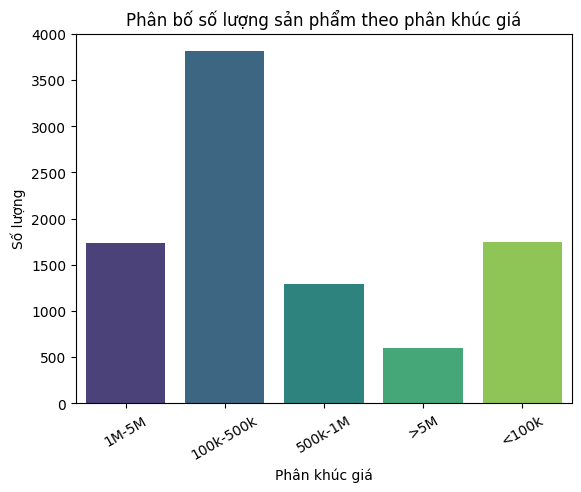

In [6]:
sns.countplot(data=df, x="price_bucket", hue="price_bucket", palette="viridis", legend=False)
plt.title("Phân bố số lượng sản phẩm theo phân khúc giá")
plt.xlabel("Phân khúc giá")
plt.ylabel("Số lượng")
plt.xticks(rotation=30)
plt.show()

#### b/Phân phối lượt bán theo phân khúc giá

C:\Users\Asus TUF\AppData\Local\Temp\ipykernel_13528\2552547321.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="price_bucket", y="sold_count", palette="Set2")


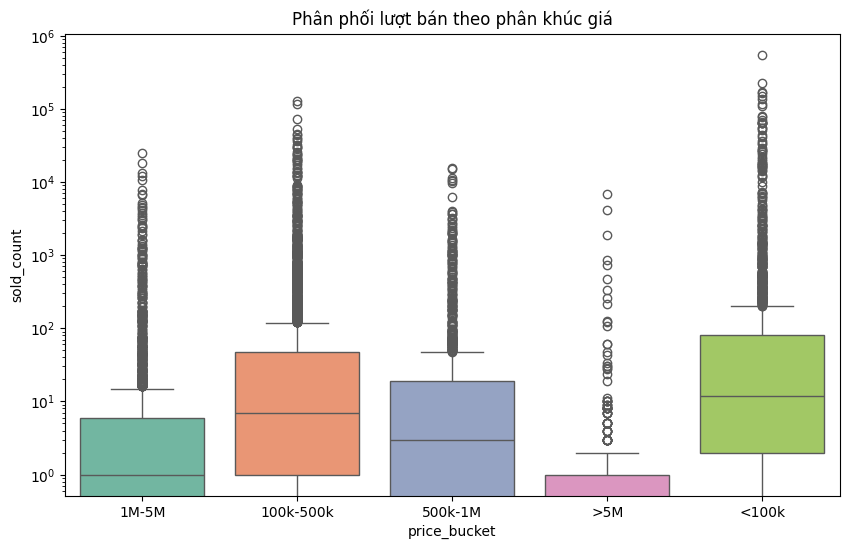

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="price_bucket", y="sold_count", palette="Set2")
plt.yscale("log")
plt.title("Phân phối lượt bán theo phân khúc giá")
plt.show()

#### c/Doanh thu và lượt bán theo phân khúc

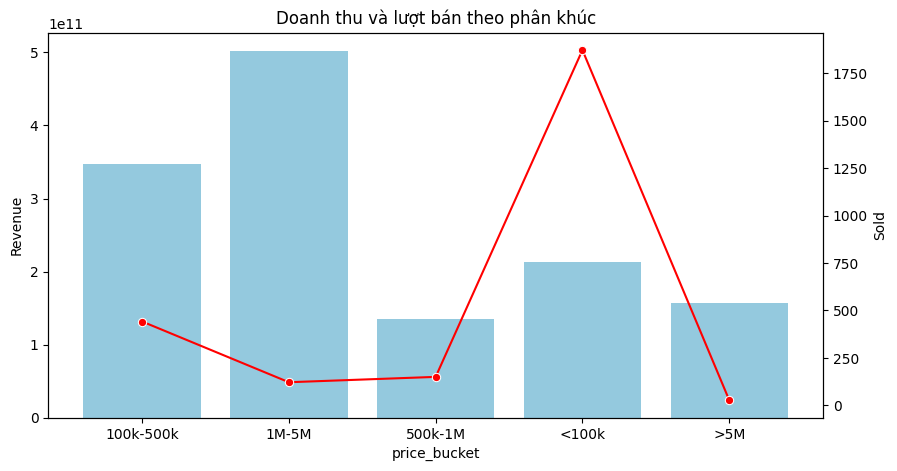

In [8]:
df['revenue'] = df['price_current'] * df['sold_count']

seg = df.groupby("price_bucket").agg({
    "revenue":"sum",
    "sold_count":"mean"
}).reset_index()

fig, ax1 = plt.subplots(figsize=(10,5))

sns.barplot(data=seg, x="price_bucket", y="revenue", ax=ax1, color="skyblue")
ax1.set_ylabel("Revenue")

ax2 = ax1.twinx()
sns.lineplot(data=seg, x="price_bucket", y="sold_count", ax=ax2, color="red", marker="o")
ax2.set_ylabel("Sold")

plt.title("Doanh thu và lượt bán theo phân khúc")
plt.show()

#### d/Sold theo Price Segment và Rating

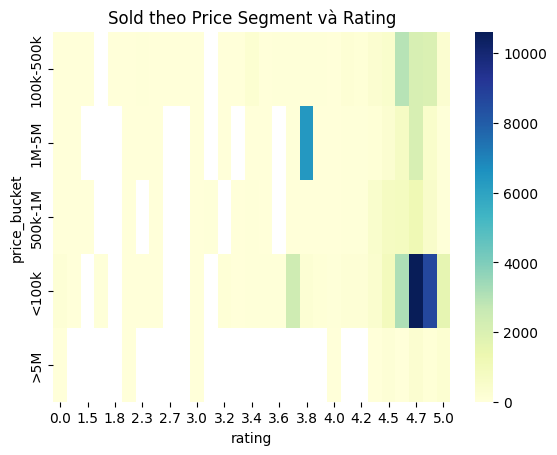

In [9]:
pivot = df.pivot_table(
    values="sold_count",
    index="price_bucket",
    columns="rating",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Sold theo Price Segment và Rating")
plt.show()

#### e/Giá vs Sold theo phân khúc

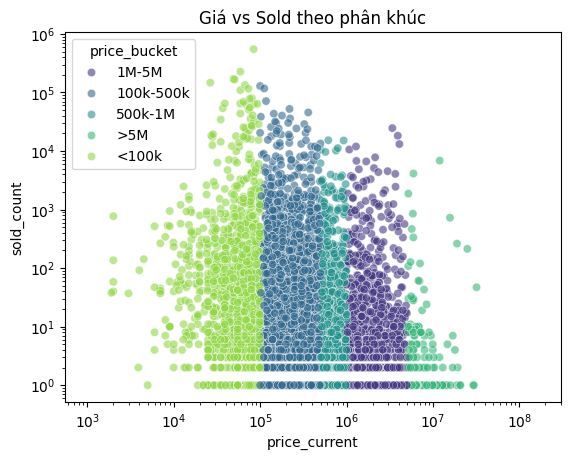

In [10]:
sns.scatterplot(
    data=df,
    x="price_current",
    y="sold_count",
    hue="price_bucket",
    palette="viridis",
    alpha=0.6
)
plt.xscale("log")
plt.yscale("log")
plt.title("Giá vs Sold theo phân khúc")
plt.show()